<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

In [153]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

In [154]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder
%cd '/content/drive/MyDrive/SDM'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SDM


In [155]:
import pandas
import numpy
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf


## Regression Models with Nonlinear Relationships
### Analyze Data Diamonds_67
Import Diamonds_67.xlsx

In [156]:
# Import data set Diamonds_67
Diamonds_67 = pandas.read_excel("data/Diamonds_67.xlsx")
# Import Fuel_Efficiency_vs_Speed.xlsx. For convenience, rename MPGData
MPGData = pandas.read_excel("data/Fuel_Efficiency_vs_Speed.xlsx")
# Import Dataset Moores_law_Intel.xlsx
Moores_law_Intel = pandas.read_excel("data/Moores_law_intel.xlsx")
# Import Dataset Linear_Model_Example_Data.xlsx. For convenience, rename MyDat.xlsx
MyDat = pandas.read_excel("data/Linear_Model_Example_Data.xlsx")
# Import Dataset Diamonds_211
Diamonds_211 = pandas.read_excel("data/Diamonds_211.xlsx")
# Import Tire_Pricing.xlsx
Tire_Pricing = pandas.read_excel("data/Tire_Pricing.xlsx")
# Import Boston_Condos_572.xlsx. For convenience, rename Boston_Condos
Boston_Condos = pandas.read_excel("data/Boston_Condos_572.xlsx")

You are not required to master the details of these plot commands, but you may find these to be a useful reference for possible future projects that you may undertake.

We will be using Price and Carat for 67 diamonds frequently. Hence, I will extract those variables from the data file so that we can use the variables without referencing the data file.

In [157]:
Price = Diamonds_67["Price"]
Carat = Diamonds_67["Carat"]

Text(0.5, 1.0, 'Price Versus Carat')

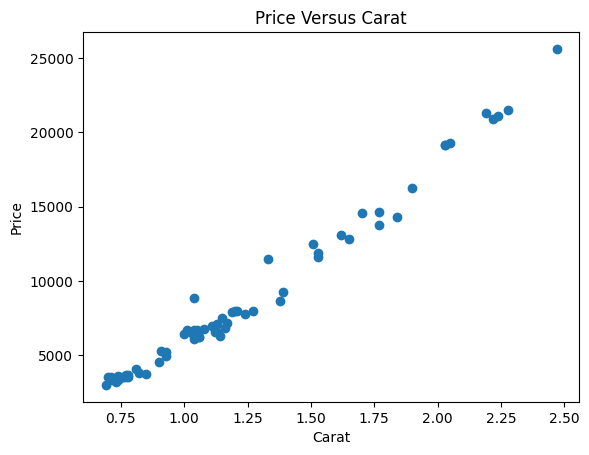

In [158]:
# Plot diamond data
plt.scatter(Carat, Price)
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Price Versus Carat")

In [159]:
# Estimate linear model
LinDiam = tprstats.model("cs", "Price ~ Carat", Diamonds_67)
LinDiam.summary()
yhat=LinDiam.predict()
resid=LinDiam.resid

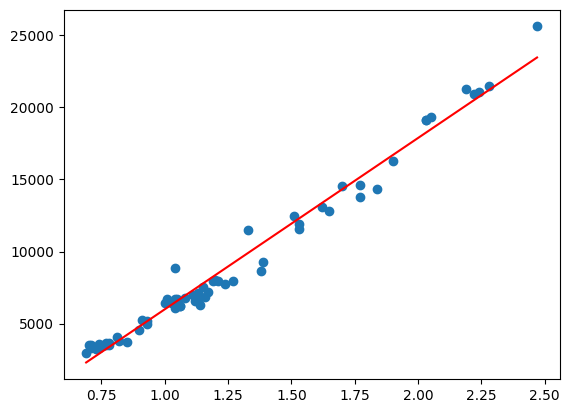

In [160]:
plt.scatter(Carat, Price)
plt.plot(Carat, yhat, color="red")

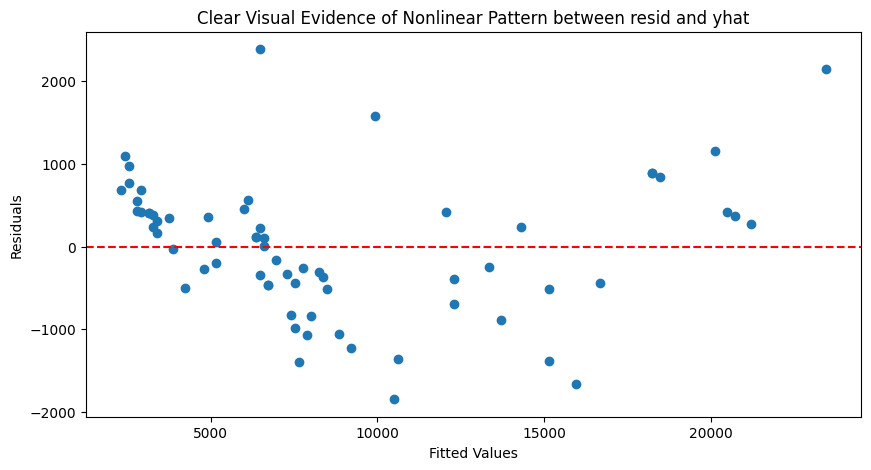

In [161]:
# Plot residuals against fitted vales
plt.figure(figsize=(10, 5))
plt.scatter(yhat, resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Clear Visual Evidence of Nonlinear Pattern between resid and yhat')
plt.show()

In [162]:
# Estimate Price vs Carat and Carat^2.
# Note the expression for the square of Carat
QuadDiam = tprstats.model("cs", "Price~Carat+ {Carat**2}", Diamonds_67)
QuadDiam.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
No. Observations:                  67   F-statistic:                     3406.
Covariance Type:                  HC1   Prob (F-statistic):           1.00e-65
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1536.9965    577.584     -2.661      0.010   -2690.852    -383.141
Carat       5043.4539    960.427      5.251      0.000    3124.780    6962.128
Carat ** 2  2348.4362    328.410      7.151      0.000    1692.362    3004.511
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [163]:
# Calculate fitted values from Quadratic Regression
QuadFit = QuadDiam.predict()

Text(0.5, 1.0, 'Actual and Predicted Prices from Quadratic')

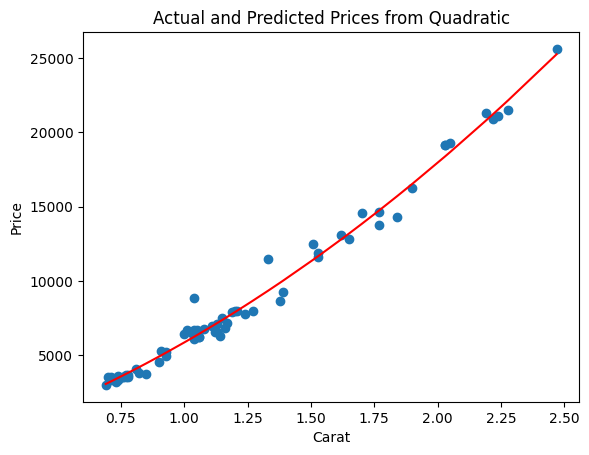

In [164]:
# Plot quadratic for diamond data
plt.scatter(Carat, Price)
plt.plot(Carat, QuadFit, color="red")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Actual and Predicted Prices from Quadratic")

Text(0, 0.5, 'log(Price)')

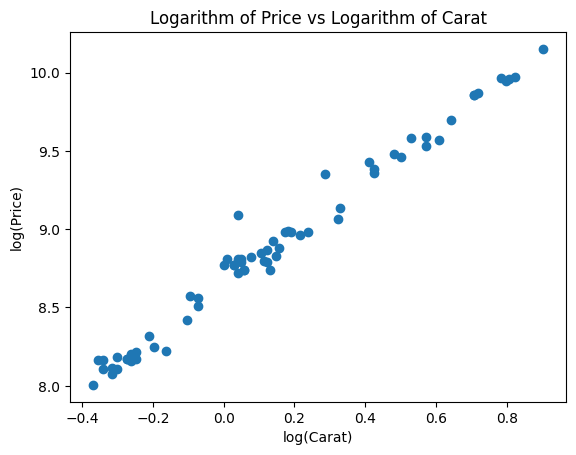

In [165]:
# Plot log of diamond Price against log of Carat
# Note use of numpy.log() to take logarithms of Carat and Price
plt.scatter(numpy.log(Carat), numpy.log(Price))
plt.title("Logarithm of Price vs Logarithm of Carat")
plt.xlabel("log(Carat)")
plt.ylabel("log(Price)")

In [166]:
# Estimate log-log model for Diamonds_65
# Note use of numpy is not required for log of a variable in a regression
# Interpret coefficient of log(Carat)
RegLogDiam67 = tprstats.model("cs", "log(Price)~log(Carat)", Diamonds_67)
RegLogDiam67.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(Price)   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
No. Observations:                  67   F-statistic:                     7871.
Covariance Type:                  HC1   Prob (F-statistic):           1.51e-69
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.6596      0.011    795.957      0.000       8.638       8.681
log(Carat)     1.6514      0.019     88.720      0.000       1.614       1.689
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [167]:
# Calculate fitted log prices.
Log_yhat = RegLogDiam67.predict()

In [168]:
# Calculate fitted Prices from log model.
# Note use of numpy.exp() to exponentiate a variable.
yhat = numpy.exp(Log_yhat)

Text(0, 0.5, 'log(Price)')

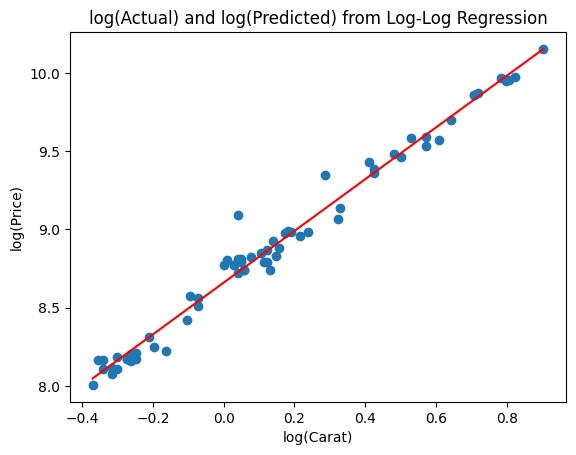

In [169]:
# Plot log(Prices) and fitted log prices against Log(Carat)
plt.scatter(numpy.log(Carat), numpy.log(Price))
plt.title("log(Actual) and log(Predicted) from Log-Log Regression")
plt.plot(numpy.log(Carat), Log_yhat, color="red")
plt.xlabel("log(Carat)")
plt.ylabel("log(Price)")

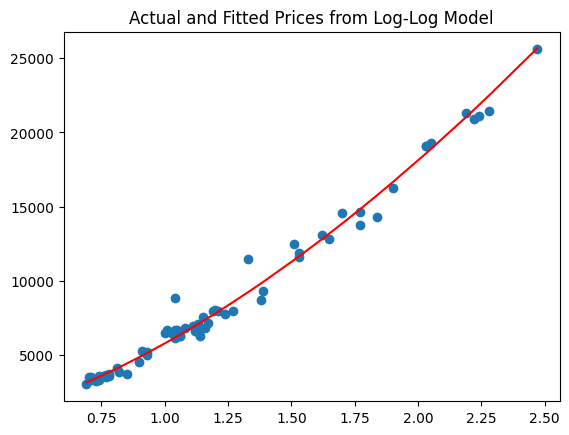

In [170]:
# Plot Prices and fitted prices against Carat using log model
plt.scatter(Carat, Price)
plt.title("Actual and Fitted Prices from Log-Log Model")
plt.plot(Carat, yhat, color="red")

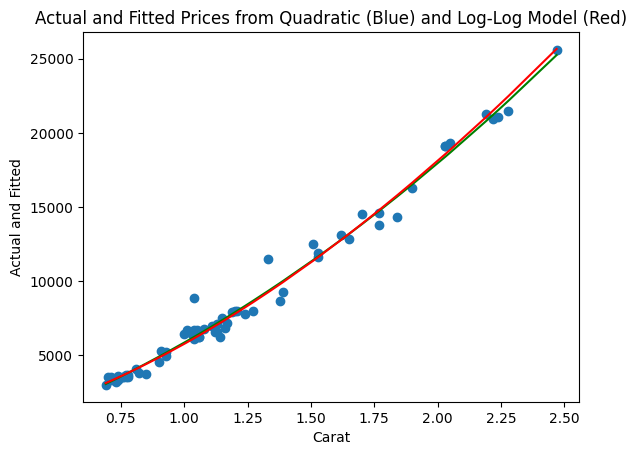

In [171]:
# Plot Prices and fitted prices from both quadratic and log models
plt.scatter(Carat, Price)
plt.ylabel("Actual and Fitted")
plt.xlabel("Carat")
plt.title("Actual and Fitted Prices from Quadratic (Blue) and Log-Log Model (Red)")
plt.plot(Carat, QuadFit, color="green")
plt.plot(Carat, yhat, color="red")

## Prediction for Models with Dependent Variable in Log Form

In [172]:
# Predicted log(Price) and prediction interval for Carat=2 using log-log regression
Xnew = pandas.DataFrame({"Carat": [2]})
RegLogDiam67.prediction_intervals(Xnew)

,Predicted,Lower,Upper
0,9.804282,9.641797,9.966766


In [173]:
# Predicted Price and prediction interval for Carat=2 using log-log regression
RegLogDiam67.prediction_intervals(Xnew).map(numpy.exp)

,Predicted,Lower,Upper
0,18111.125492,15394.985664,21306.474311


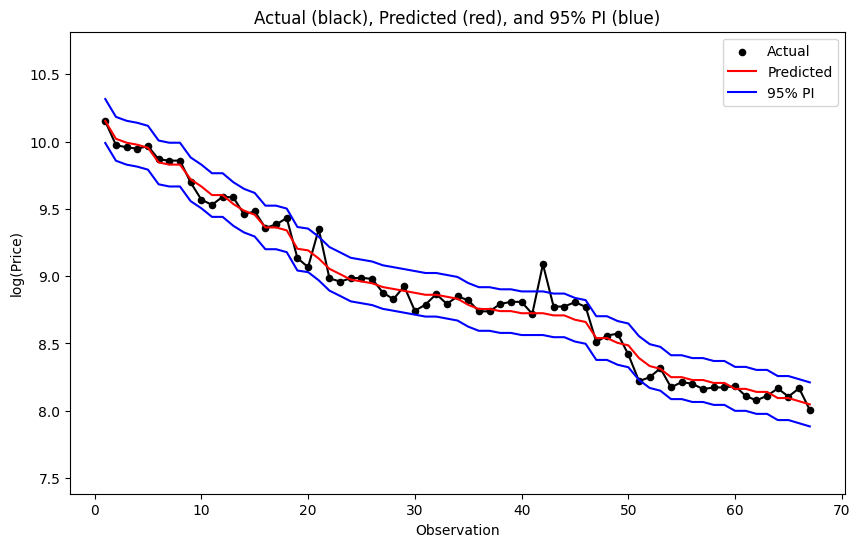

In [174]:
# Plot actual and fitted log prices
# and 95% prediction intervals.
RegLogDiam67.plot_actual_fitted()

## Models with a Quadratic Functional Form for an Explanatory Variable
### Analyze Fuel Efficiency

In [175]:
# Estimate a linear model of MPG vs Speed
LinMPG = tprstats.model("cs", "MPG~Speed", MPGData)
LinMPG.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.377
No. Observations:                  50   F-statistic:                     19.44
Covariance Type:                  HC1   Prob (F-statistic):           5.82e-05
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.7673      1.128     29.055      0.000      30.500      35.035
Speed          0.1061      0.024      4.409      0.000       0.058       0.154
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [176]:
# Calculate fitted values from linear regression and name LinFit
LinFit = LinMPG.predict()

In [177]:
# For convenience, extract these variables.
MPG = MPGData["MPG"]
Speed = MPGData["Speed"]
# We can now  use the variables without referencing the data file

Text(0.5, 1.0, 'Linear Model of MPG versus Speed')

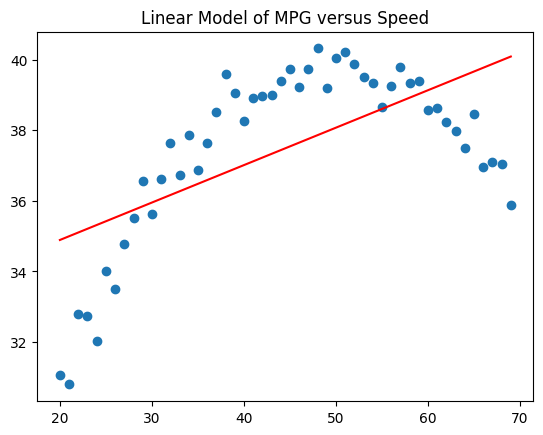

In [178]:
# Plot data and fit from linear regression equation
plt.scatter(Speed, MPG)
plt.plot(Speed, LinFit, color="red")
plt.title("Linear Model of MPG versus Speed")

In [179]:
# Estimate a quadratic in MPG vs Speed
# You can use either I(Speed**2) or {Speed**2}
QuadMPG = tprstats.model("cs", "MPG ~ Speed + {Speed**2}", MPGData)
QuadMPG.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.956
No. Observations:                  50   F-statistic:                     451.7
Covariance Type:                  HC1   Prob (F-statistic):           2.06e-31
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.1718      0.779     19.479      0.000      13.605      16.739
Speed          0.9899      0.035     27.905      0.000       0.918       1.061
Speed ** 2    -0.0099      0.000    -25.966      0.000      -0.011      -0.009
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.56e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [180]:
# Calculate fitted values from quadratic regression
QuadFit = QuadMPG.predict()

Text(0.5, 1.0, 'Quadratic Fits Nicely')

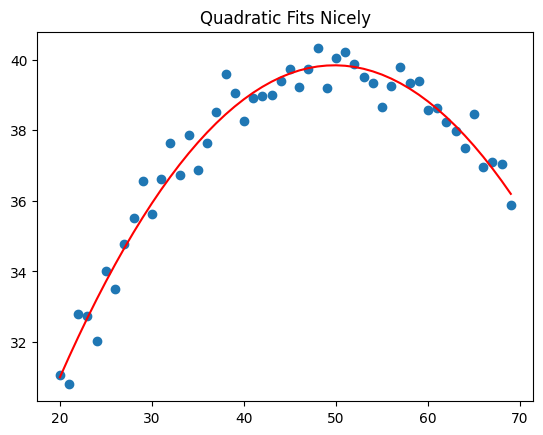

In [181]:
# Plot  quadratic for fuel efficiency
plt.scatter(Speed, MPG)
plt.plot(Speed, QuadFit, color="red")
plt.title("Quadratic Fits Nicely")

In [182]:
# Predict mpg if speed=70 and form prediction interval. Note in this command
# that you need only enter the value for Speed. In doing the prediction,
# the software automatically calculates and includes the term in Speed^2.
Xnew = pandas.DataFrame({"Speed": [70]})
QuadMPG.prediction_intervals(Xnew)

,Predicted,Lower,Upper
0,35.805761,34.689577,36.921945


In [183]:
# For convenience, extract variables from the file
Transistors = Moores_law_Intel["Transistors"]
Time = Moores_law_Intel["Time"]

Text(0.5, 1.0, 'Transistors Per Chip')

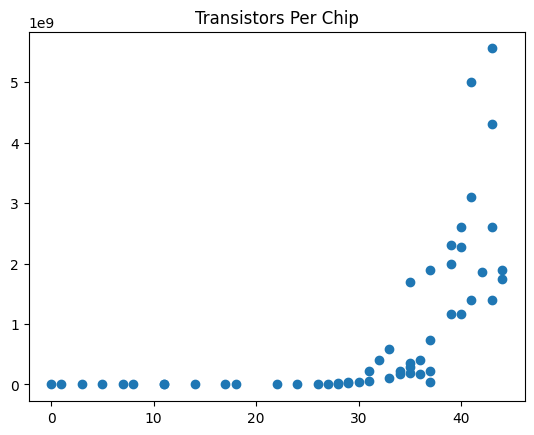

In [184]:
# Plot Transistors Per Chip over time
plt.scatter(Time, Transistors)
plt.title("Transistors Per Chip")

Text(0.5, 1.0, 'Transistors Per Chip')

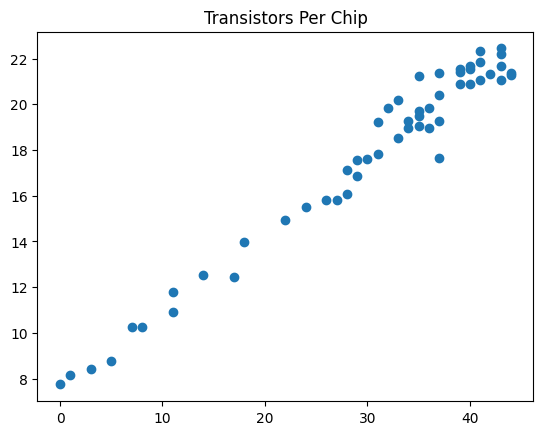

In [185]:
# Plot log(Transistors) over time
plt.scatter(Time, numpy.log(Transistors))
plt.title("Transistors Per Chip")

In [186]:
# Estimate Moore's law regression
MooreReg = tprstats.model("cs", "log(Transistors)~Time", Moores_law_Intel)
MooreReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       log(Transistors)   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
No. Observations:                  53   F-statistic:                     3223.
Covariance Type:                  HC1   Prob (F-statistic):           9.06e-48
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6034      0.149     50.940      0.000       7.304       7.903
Time           0.3369      0.006     56.774      0.000       0.325       0.349
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

Text(0.5, 1.0, "Moore's Law")

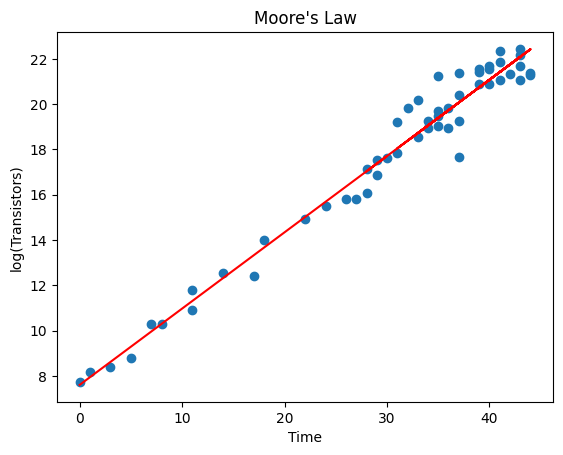

In [187]:
# Do a Scatterplot of log(Transistors) versus Time
plt.scatter(Time, numpy.log(Transistors))
# Add Regression Line
yhat = MooreReg.predict()
plt.plot(Time, yhat, color="red")
plt.xlabel("Time")
plt.ylabel("log(Transistors)")
plt.title("Moore's Law")

## Nonlinear Relationships: Ramsey Test

### Testing Functional Form with Linear Model Example Data

In [188]:
# For this application, we use data set Linear_Model_Example_Data.xlsx which we renamed MyDat

In [189]:
RegExample = tprstats.model("cs", "y~x1+x2", MyDat)
RegExample.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.844
No. Observations:                 299   F-statistic:                     759.0
Covariance Type:                  HC1   Prob (F-statistic):          2.98e-117
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8153      0.071     39.437      0.000       2.675       2.956
x1             2.3103      0.094     24.678      0.000       2.126       2.494
x2             3.0189      0.095     31.918      0.000       2.833       3.205
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [190]:
yhat=RegExample.fittedvalues
resid=RegExample.resid

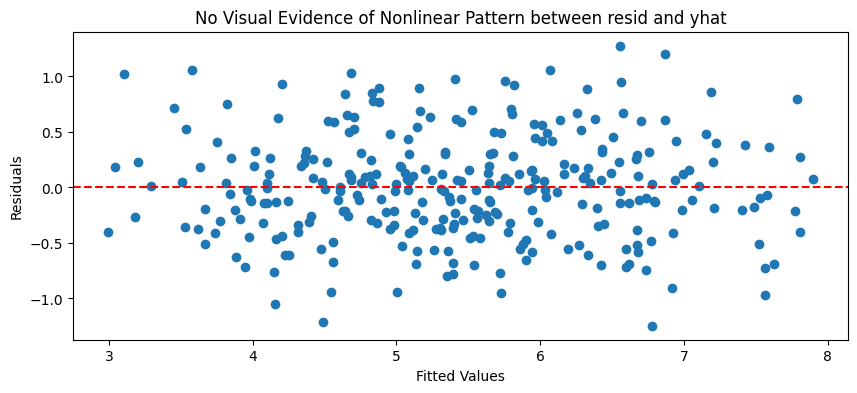

In [191]:
plt.figure(figsize=(10, 4))
plt.scatter(yhat, resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('No Visual Evidence of Nonlinear Pattern between resid and yhat')
plt.show()

In [192]:
MyDat2 = pandas.DataFrame({ 'resid': resid, 'yhat': yhat, 'yhatsq': yhat**2 })

A regression of the residuals against yhat and the square of yhat yields insignificant coefficients. This reinforces the conclusion from the above graph that there is not a nonlinear relationship between the residuals and the fitted values (yhat).

In [193]:
ResidReg = tprstats.model("cs", "resid~yhat+yhatsq",data=MyDat2)
ResidReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  resid   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.007
No. Observations:                 299   F-statistic:                   0.01306
Covariance Type:                  HC1   Prob (F-statistic):              0.987
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0926      0.592     -0.157      0.876      -1.257       1.072
yhat           0.0352      0.219      0.160      0.873      -0.396       0.466
yhatsq        -0.0032      0.020     -0.162      0.872      -0.042       0.036
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [194]:
Diamonds_211 = pandas.read_excel("data/Diamonds_211.xlsx")

In [195]:
LinDiam211 = tprstats.model("cs", "Price~Carat+Clarity", Diamonds_211)
yhat=LinDiam211.fittedvalues
resid=LinDiam211.resid

In [196]:
MyDat3 = pandas.DataFrame({ 'resid': resid, 'yhat': yhat, 'yhatsq': yhat**2 })

In [197]:
ResidReg = tprstats.model("cs", "resid~yhat+yhatsq",data=MyDat3)
ResidReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  resid   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.244
No. Observations:                 211   F-statistic:                     46.89
Covariance Type:                  HC1   Prob (F-statistic):           1.56e-17
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1690.0675    173.882      9.720      0.000    1347.270    2032.865
yhat          -0.4399      0.049     -8.892      0.000      -0.537      -0.342
yhatsq      2.005e-05   2.74e-06      7.314      0.000    1.46e-05    2.55e-05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 5.38e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

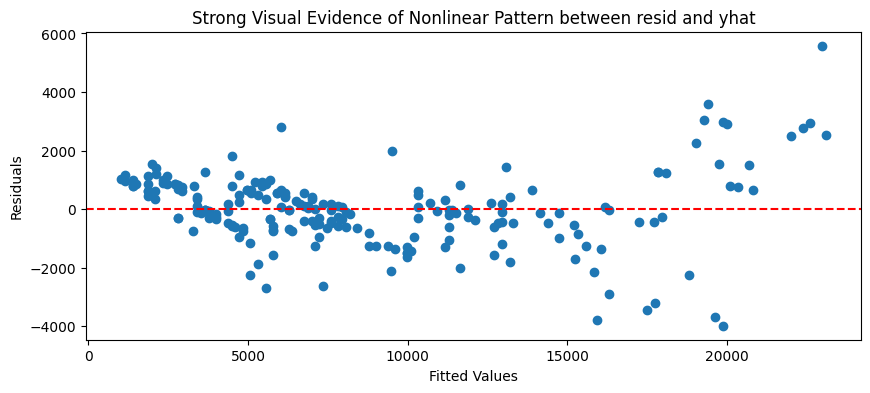

In [198]:
plt.figure(figsize=(10, 4))
plt.scatter(yhat, resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Strong Visual Evidence of Nonlinear Pattern between resid and yhat')
plt.show()

## Diamonds_67 Example
To illustrate the Ramsey test, we use Diamonds_67.xlsx.

In [199]:
# For convenience, extract variables from data file
Price = Diamonds_67["Price"]
Carat = Diamonds_67["Carat"]

# Also for convenience take the logs
log_price = numpy.log(Price)
log_carat = numpy.log(Carat)

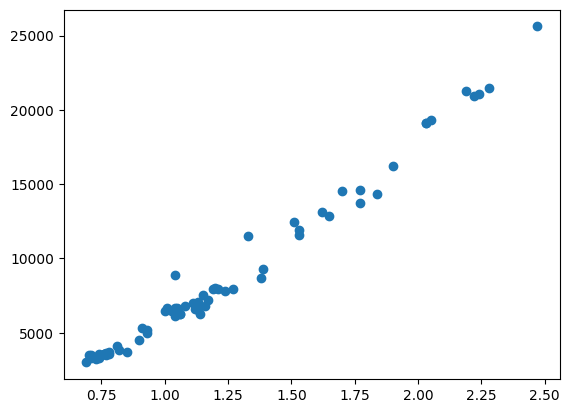

In [126]:
# View plot of Price vs Carat
plt.scatter(Carat, Price)

In [127]:
# Linear model of Diamonds_67
LinDiam = tprstats.model("cs", "Price~Carat", Diamonds_67)
LinDiam.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.978
No. Observations:                  67   F-statistic:                     2074.
Covariance Type:                  HC1   Prob (F-statistic):           4.88e-51
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -5889.1329    299.710    -19.649      0.000   -6487.695   -5290.570
Carat       1.188e+04    260.897     45.541      0.000    1.14e+04    1.24e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

Below we plot the residuals against the fitted values from the above regression. Note that the data points to the left are disproportionately above zero and the same is true for the data points at the right. Toward the middle, the data points are disproportionately below zero. This suggests that there is a nonlinear pattern in the data that is not being captured by the fitted values. Hence, it suggests that we try an alternative functional form.

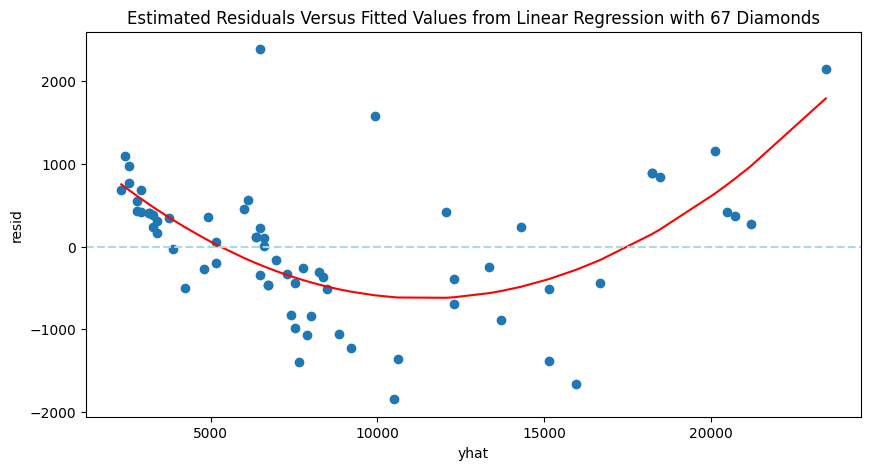

In [128]:
# View plot of resid vs yhat with quadratic fit
resid=LinDiam.resid
yhat=LinDiam.predict()
plt.figure(figsize=(10, 5))
plt.scatter(yhat, resid)
df = pandas.DataFrame({ 'resid': resid, 'yhat': yhat, 'yhatsq': yhat**2 })
residreg=tprstats.model("cs","resid~yhat + yhatsq", df)
reshat=residreg.predict()
plt.plot(yhat, reshat, color="red")
plt.axhline(y=0, color='lightblue', linestyle='--')
plt.title("Estimated Residuals Versus Fitted Values from Linear Regression with 67 Diamonds")
plt.xlabel("yhat")
plt.ylabel("resid")
plt.show()

In [129]:
# Ramsey reset test yields low p-values
# This is evidence that the linear functional form does not fit well
LinDiam.ramsey_test()

,power,pvalue
0,2,1.828668e-08
1,3,1.428546e-07


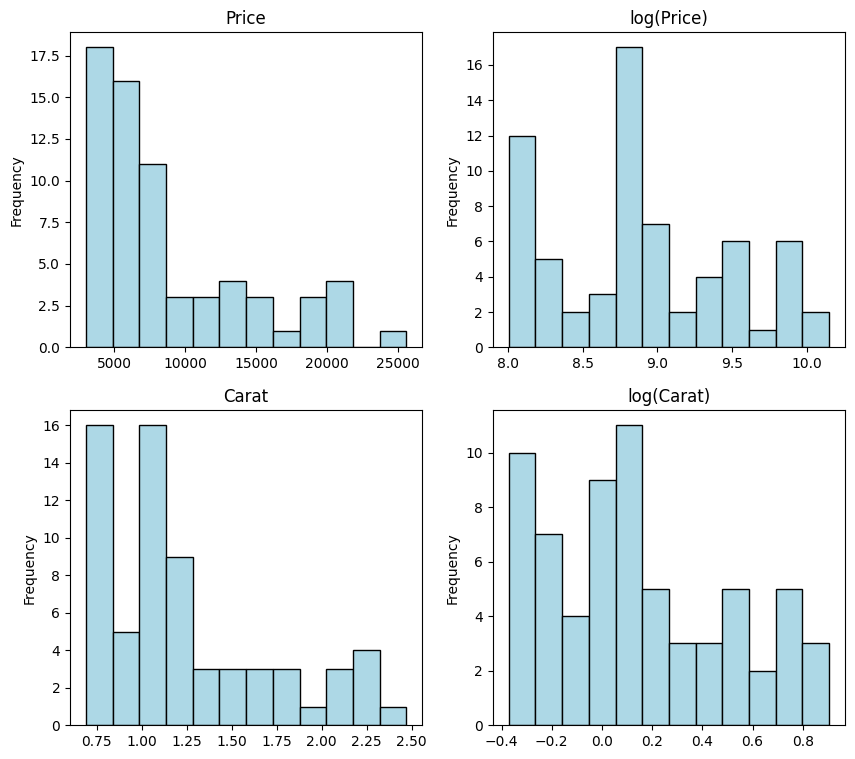

In [130]:
# View histograms of variables
fig, axes = plt.subplots(nrows=2, ncols=2)
Diamonds_67["Price"].plot.hist(ax=axes[0, 0], bins=12, title="Price", figsize=(10, 9), edgecolor="black",
    color="lightblue")
Diamonds_67["Price"].map(numpy.log).plot.hist(ax=axes[0, 1], bins=12, title="log(Price)", figsize=(10, 9), edgecolor="black",color="lightblue")
Diamonds_67["Carat"].plot.hist(ax=axes[1, 0], bins=12, title="Carat", figsize=(10, 9),edgecolor="black",color="lightblue")
Diamonds_67["Carat"].map(numpy.log).plot.hist(ax=axes[1, 1], bins=12, title="log(Carat)", figsize=(10, 9),edgecolor="black",
    color="lightblue")
plt.show()

In the above histograms, Price is skewed. log(Price) is more balanced. Similarly Carat is skewed. log(Carat) is more balanced.                                                      
These histograms suggest estimating a model with logarithms of Price and Carat.

In [131]:
# Estimate log-log model for Diamonds_67
LogDiam67 = tprstats.model("cs", "log(Price)~log(Carat)", Diamonds_67)
LogDiam67.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(Price)   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
No. Observations:                  67   F-statistic:                     7871.
Covariance Type:                  HC1   Prob (F-statistic):           1.51e-69
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.6596      0.011    795.957      0.000       8.638       8.681
log(Carat)     1.6514      0.019     88.720      0.000       1.614       1.689
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [132]:
# Ramsey test of log model of Diamonds_67
# High p-values are favorable to this functional form
LogDiam67.ramsey_test()

,power,pvalue
0,2,0.220270
1,3,0.409141


## Nonlinear Relationships: Leverage Plots
### Diamonds_211 Leverage Plot Example

In [133]:
# Estimate linear model (same as before)
LinDiam211 = tprstats.model("cs", "Price~Carat+Clarity", Diamonds_211)
LinDiam211.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
No. Observations:                 211   F-statistic:                     773.8
Covariance Type:                  HC1   Prob (F-statistic):           4.54e-97
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -1.16e+04    759.549    -15.278      0.000   -1.31e+04   -1.01e+04
Carat       1.193e+04    314.094     37.973      0.000    1.13e+04    1.25e+04
Clarity     1308.8177    124.664     10.499      0.000    1063.051    1554.584
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [134]:
# Ramsey test strongly rejects linear model
LinDiam211.ramsey_test()

,power,pvalue
0,2,4.543476e-15
1,3,1.785422e-16


When we reject a linear model with a Ramsey test, we then confront the question of what functional form to try. Above we saw that histograms were helpful in suggesting logarithms of Price and Carat. Leverage plots can sometimes be helpful in making a judgment about what functional to try. The goal of a leverage plot is to show the effect of a given independent variable on the dependent variable while holding other variables constant. I will not test you on leverage plots, but it is useful for you to be familiar with the idea.

As you can see below, Colab uses the label "Partial Regression Plot" instead of Leverage plot, but the meanings are the same. The command below plots the relationship of Price and Carat holding Clarity constant. Note that putting 'Clarity' in square brackets is how we tell the command which variable to hold constant. The leverage plot below suggests trying a model with logarithms of Price and Carat.

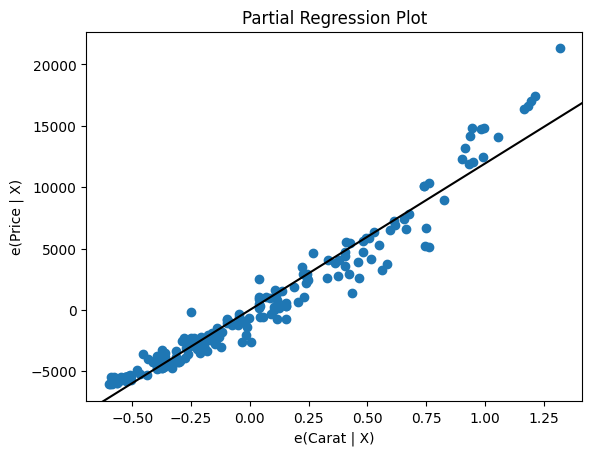

In [135]:
sm.graphics.plot_partregress('Price', 'Carat', ['Clarity'], data=Diamonds_211, obs_labels=False)
plt.show()

The leverage plot below shows the relationship of Price and Clarity holding Carat constant. This plot is less informative about functional form. Hence, the natural next step is to estimate a model using logarithms of Price and Clarity to see if that improves the model.

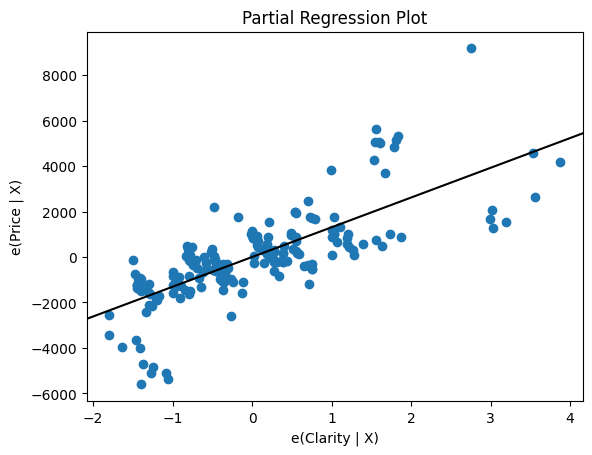

In [136]:
sm.graphics.plot_partregress('Price', 'Clarity', ['Carat'], data=Diamonds_211, obs_labels=False)
plt.show()

In [137]:
# Estimate model with log(Price) and log(Carat)
LogDiam211 = tprstats.model("cs", "log(Price) ~ log(Carat) + Clarity", Diamonds_211)
LogDiam211.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(Price)   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
No. Observations:                 211   F-statistic:                     8249.
Covariance Type:                  HC1   Prob (F-statistic):          7.90e-199
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.1878      0.026    315.824      0.000       8.137       8.239
log(Carat)     1.6570      0.013    128.323      0.000       1.632       1.683
Clarity        0.1111      0.006     19.511      0.000       0.100       0.122
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

The leverage plot below suggests that the model with logarithms of Price and Carat captures the relationship between Price and Carat quite well.

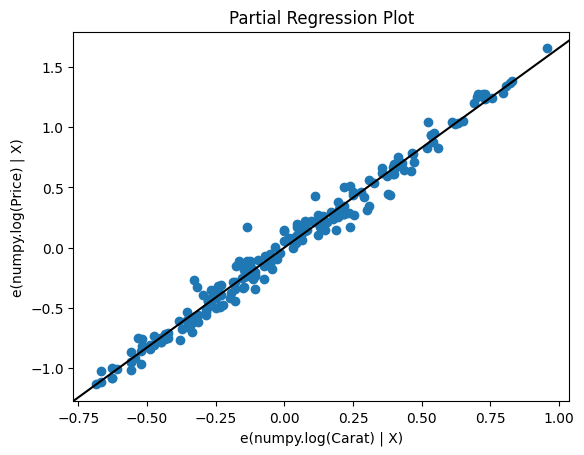

In [138]:
sm.graphics.plot_partregress('numpy.log(Price)', 'numpy.log(Carat)', ['Clarity'], data=Diamonds_211, obs_labels=False)
plt.show()

The leverage plot with respect to Clarity also appears to be improved somewhat.

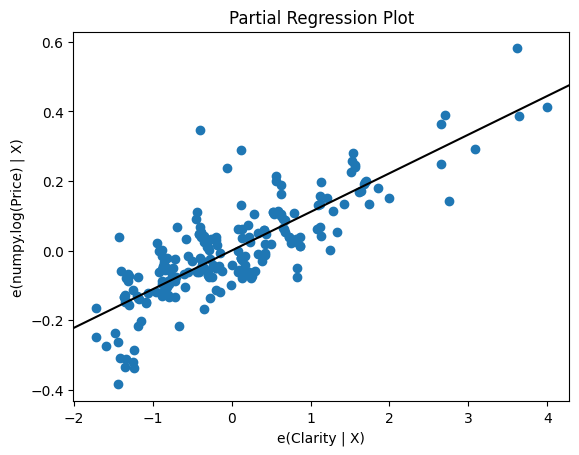

In [139]:
sm.graphics.plot_partregress('numpy.log(Price)','Clarity', ['numpy.log(Carat)'], data=Diamonds_211, obs_labels=False)
plt.show()

In [140]:
# The Ramsey test for the model with log(Price) versus log(Carat) and Clarity suggests this model is an improvement
# However, the test with one fitted terms gives somewhat low p-value
LogDiam211.ramsey_test()

,power,pvalue
0,2,0.108773
1,3,0.223342


In [141]:
# Estimate with indicator variables for Clarity
LogFacDiam211 = tprstats.model("cs", "log(Price) ~ log(Carat) + C(Clarity)", Diamonds_211)
LogFacDiam211.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(Price)   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
No. Observations:                 211   F-statistic:                     3664.
Covariance Type:                  HC1   Prob (F-statistic):          1.00e-204
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           8.2714      0.024    338.584      0.000       8.223       8.320
log(Carat)          1.6714      0.012    137.116      0.000       1.647       1.695
C(Clarity)[T.3]     0.2641      0.025     10.610      0.000       0.215       0.313
C(Clarity)[T.4]     0.3853      0.025     15.145      0.000       0.335       0.435
C(Clarity)[T.5]     0.4634      0.026     17.850      0.000       0.412       0.515
C(Clarity)[T.6]     0.5368      0.029     18.310      0.000       0.479       0.595
C(Clarity)[T.8]     0.8032      0.046     17.397      0.000       0.712       0.894
===================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [142]:
# Ramsey test now gives high p-values for both 1 and 2 fitted terms
# These high p-values are favorable to his functional form
LogFacDiam211.ramsey_test()

,power,pvalue
0,2,0.628253
1,3,0.867617


In [143]:
# Test null hypothesis that population coefficient of Clarity=3 is same as Clarity=4
# This low p-value strongly rejects the null hypothesis
LogFacDiam211.wald_test("C(Clarity)[T.3] = C(Clarity)[T.4]")

p-value:  0.0


In [144]:
# Prediction for Summit Jewelers, Carat=2.1 and Clarity = 7
Xnew = pandas.DataFrame({"Carat": [2.1], "Clarity": [6]})
y_pred = LogFacDiam211.prediction_intervals(Xnew)
exp_ypred = y_pred.map(numpy.exp)
exp_ypred

,Predicted,Lower,Upper
0,23115.511663,19878.82351,26879.200329


In [145]:
# As another application of the Ramsey test, we use our Alum's Tire Pricing model.
# This gives relatively high p-values.

In [146]:
TireReg = tprstats.model("cs", "Price~Diameter+Ratio+Terrain+Weight+Tread+Volume+WW+OWL+H+V+Z", Tire_Pricing)

In [147]:
# Ramsey test of tire model
TireReg.ramsey_test()

,power,pvalue
0,2,0.130708
1,3,0.300243
